# Portfolio Risk Decomposition

This notebook extends the market-risk engine from aggregate portfolio risk
measurement to risk attribution.

The analysis includes:

- Marginal VaR
- Component VaR
- Standalone VaR
- Diversification benefit
- Incremental VaR
- Risk concentration
- Stress-period risk contributions

The objective is to identify which positions drive portfolio risk and how
diversification changes the relationship between individual and aggregate
risk.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import norm

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
CHARTS_DIR = PROJECT_ROOT / "outputs" / "charts"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\Pranav\Desktop\market-risk-engine


In [2]:
returns_path = PROCESSED_DATA_DIR / "daily_returns.csv"
pnl_path = PROCESSED_DATA_DIR / "daily_pnl.csv"

if not returns_path.exists():
    raise FileNotFoundError(
        "daily_returns.csv was not found. Run the Day 1 notebook first."
    )

if not pnl_path.exists():
    raise FileNotFoundError(
        "daily_pnl.csv was not found. Run the Day 1 notebook first."
    )

returns = pd.read_csv(
    returns_path,
    index_col="date",
    parse_dates=True,
).sort_index()

pnl_data = pd.read_csv(
    pnl_path,
    index_col="date",
    parse_dates=True,
).sort_index()

portfolio_pnl = pnl_data["portfolio_pnl_eur"].copy()

print(f"Return observations: {len(returns):,}")
print(f"P&L observations: {len(portfolio_pnl):,}")

print(
    f"Sample: {returns.index.min().date()} "
    f"to {returns.index.max().date()}"
)

display(returns.head())

Return observations: 2,654
P&L observations: 2,654
Sample: 2016-01-05 to 2026-07-31


,Equity index,Government bond proxy,EUR/USD,Gold
date,,,,
2016-01-05,0.001691,-0.004035,-0.002436,0.002819
2016-01-06,-0.012614,0.013476,-0.006978,0.014441
2016-01-07,-0.023992,0.001795,0.002512,0.014140
2016-01-08,-0.010976,0.004478,0.013636,-0.004428
2016-01-11,0.000990,-0.010943,0.001379,-0.008895


## 1. Portfolio and risk-decomposition framework

Risk decomposition is initially performed using the Parametric Normal VaR
framework.

For a portfolio with exposure vector \(\mathbf{w}\) and return covariance
matrix \(\Sigma\), portfolio volatility is

\[
\sigma_P
=
\sqrt{\mathbf{w}^{\top}\Sigma\mathbf{w}}.
\]

At confidence level \(c\), zero-mean Parametric VaR is

\[
VaR_P
=
z_c\sigma_P.
\]

Although more advanced VaR models were developed in Day 3, the variance-
covariance model is particularly useful for risk attribution because VaR can
be decomposed exactly into additive position-level contributions.

In [3]:
CONFIDENCE_LEVEL = 0.99
LOOKBACK_WINDOW = 250

Z_SCORE = norm.ppf(CONFIDENCE_LEVEL)

NOTIONALS = pd.Series(
    {
        "Equity index": 250_000,
        "Government bond proxy": 300_000,
        "EUR/USD": 200_000,
        "Gold": 150_000,
    },
    dtype=float,
)

assert list(NOTIONALS.index) == list(returns.columns)
assert NOTIONALS.sum() == 900_000

print(f"Confidence level: {CONFIDENCE_LEVEL:.0%}")
print(f"Lookback window: {LOOKBACK_WINDOW} days")
print(f"Normal VaR multiplier: {Z_SCORE:.4f}")
print(f"Gross exposure: EUR {NOTIONALS.sum():,.0f}")

display(
    NOTIONALS.to_frame("notional_eur").style.format(
        {"notional_eur": "EUR {:,.0f}"}
    )
)

Confidence level: 99%
Lookback window: 250 days
Normal VaR multiplier: 2.3263
Gross exposure: EUR 900,000


,notional_eur
Equity index,"EUR 250,000"
Government bond proxy,"EUR 300,000"
EUR/USD,"EUR 200,000"
Gold,"EUR 150,000"


In [4]:
recent_returns = returns.iloc[
    -LOOKBACK_WINDOW:
].copy()

covariance_matrix = recent_returns.cov()

correlation_matrix = recent_returns.corr()

display(
    correlation_matrix.style.format("{:.3f}")
)

,Equity index,Government bond proxy,EUR/USD,Gold
Equity index,1.000,0.218,0.078,0.320
Government bond proxy,0.218,1.000,-0.077,0.099
EUR/USD,0.078,-0.077,1.000,0.102
Gold,0.320,0.099,0.102,1.000


### Correlation and diversification

Portfolio risk depends not only on the volatility of individual positions but
also on their correlations.

Two individually risky positions can reduce aggregate portfolio risk if their
returns are imperfectly or negatively correlated.

Risk decomposition therefore differs from simply ranking positions by their
notional exposure or standalone volatility.

In [5]:
notional_vector = NOTIONALS.reindex(
    returns.columns
).to_numpy(dtype=float)

covariance_array = covariance_matrix.to_numpy(
    dtype=float
)

portfolio_variance = float(
    notional_vector
    @ covariance_array
    @ notional_vector
)

portfolio_variance = max(
    portfolio_variance,
    0.0,
)

portfolio_volatility_eur = np.sqrt(
    portfolio_variance
)

portfolio_var_eur = (
    Z_SCORE
    * portfolio_volatility_eur
)

print(
    f"Current portfolio volatility: "
    f"EUR {portfolio_volatility_eur:,.2f}"
)

print(
    f"Current 99% Parametric VaR: "
    f"EUR {portfolio_var_eur:,.2f}"
)

Current portfolio volatility: EUR 4,598.94
Current 99% Parametric VaR: EUR 10,698.74


## 2. Marginal VaR

Marginal VaR measures the local sensitivity of total portfolio VaR to a small
increase in an individual position.

For position \(i\),

\[
MVaR_i
=
\frac{\partial VaR_P}{\partial w_i}
=
z_c
\frac{(\Sigma\mathbf{w})_i}{\sigma_P}.
\]

Because exposures are expressed in EUR, Marginal VaR is interpreted as the
approximate change in portfolio VaR resulting from one additional EUR of
exposure.

A negative Marginal VaR indicates that increasing the position would reduce
portfolio risk at the current portfolio composition.

In [6]:
covariance_times_exposure = (
    covariance_array
    @ notional_vector
)

marginal_var = (
    Z_SCORE
    * covariance_times_exposure
    / portfolio_volatility_eur
)

marginal_var_series = pd.Series(
    marginal_var,
    index=returns.columns,
    name="marginal_var_per_eur",
)

display(
    marginal_var_series.to_frame().style.format(
        {
            "marginal_var_per_eur": (
                "EUR {:,.6f}"
            )
        }
    )
)

,marginal_var_per_eur
Equity index,EUR 0.013525
Government bond proxy,EUR 0.007047
EUR/USD,EUR 0.002067
Gold,EUR 0.031933


## 3. Component VaR

Component VaR converts Marginal VaR into the amount of total portfolio VaR
attributable to each position:

\[
CVaR_i
=
w_i MVaR_i.
\]

Under the variance-covariance framework, Euler's theorem implies:

\[
VaR_P
=
\sum_i CVaR_i.
\]

Component VaR therefore provides an additive risk attribution.

A negative Component VaR means that the position currently reduces aggregate
portfolio risk through diversification.

In [7]:
component_var = (
    NOTIONALS
    * marginal_var_series
)

component_var_pct = (
    component_var
    / portfolio_var_eur
)

component_var_results = pd.DataFrame(
    {
        "notional_eur": NOTIONALS,
        "marginal_var_per_eur": marginal_var_series,
        "component_var_eur": component_var,
        "component_var_pct": component_var_pct,
    }
)

component_var_results["notional_pct"] = (
    component_var_results["notional_eur"]
    / NOTIONALS.sum()
)

component_var_results = (
    component_var_results[
        [
            "notional_eur",
            "notional_pct",
            "marginal_var_per_eur",
            "component_var_eur",
            "component_var_pct",
        ]
    ]
)

display(
    component_var_results.style.format(
        {
            "notional_eur": "EUR {:,.0f}",
            "notional_pct": "{:.2%}",
            "marginal_var_per_eur": "EUR {:.6f}",
            "component_var_eur": "EUR {:,.2f}",
            "component_var_pct": "{:.2%}",
        }
    )
)

,notional_eur,notional_pct,marginal_var_per_eur,component_var_eur,component_var_pct
Equity index,"EUR 250,000",27.78%,EUR 0.013525,"EUR 3,381.28",31.60%
Government bond proxy,"EUR 300,000",33.33%,EUR 0.007047,"EUR 2,114.13",19.76%
EUR/USD,"EUR 200,000",22.22%,EUR 0.002067,EUR 413.37,3.86%
Gold,"EUR 150,000",16.67%,EUR 0.031933,"EUR 4,789.96",44.77%


In [8]:
component_var_sum = (
    component_var_results[
        "component_var_eur"
    ].sum()
)

decomposition_difference = (
    component_var_sum
    - portfolio_var_eur
)

print(
    f"Portfolio VaR: "
    f"EUR {portfolio_var_eur:,.6f}"
)

print(
    f"Sum of Component VaR: "
    f"EUR {component_var_sum:,.6f}"
)

print(
    f"Decomposition difference: "
    f"EUR {decomposition_difference:,.10f}"
)

assert np.isclose(
    component_var_sum,
    portfolio_var_eur,
    rtol=1e-10,
    atol=1e-8,
)

print("Euler VaR decomposition validated successfully.")

Portfolio VaR: EUR 10,698.737760
Sum of Component VaR: EUR 10,698.737760
Decomposition difference: EUR 0.0000000000
Euler VaR decomposition validated successfully.


In [9]:
risk_concentration_comparison = (
    component_var_results[
        [
            "notional_pct",
            "component_var_pct",
        ]
    ]
    .copy()
)

risk_concentration_comparison[
    "risk_minus_notional_share"
] = (
    risk_concentration_comparison[
        "component_var_pct"
    ]
    - risk_concentration_comparison[
        "notional_pct"
    ]
)

display(
    risk_concentration_comparison.style.format(
        {
            "notional_pct": "{:.2%}",
            "component_var_pct": "{:.2%}",
            "risk_minus_notional_share": "{:+.2%}",
        }
    )
)

,notional_pct,component_var_pct,risk_minus_notional_share
Equity index,27.78%,31.60%,+3.83%
Government bond proxy,33.33%,19.76%,-13.57%
EUR/USD,22.22%,3.86%,-18.36%
Gold,16.67%,44.77%,+28.10%


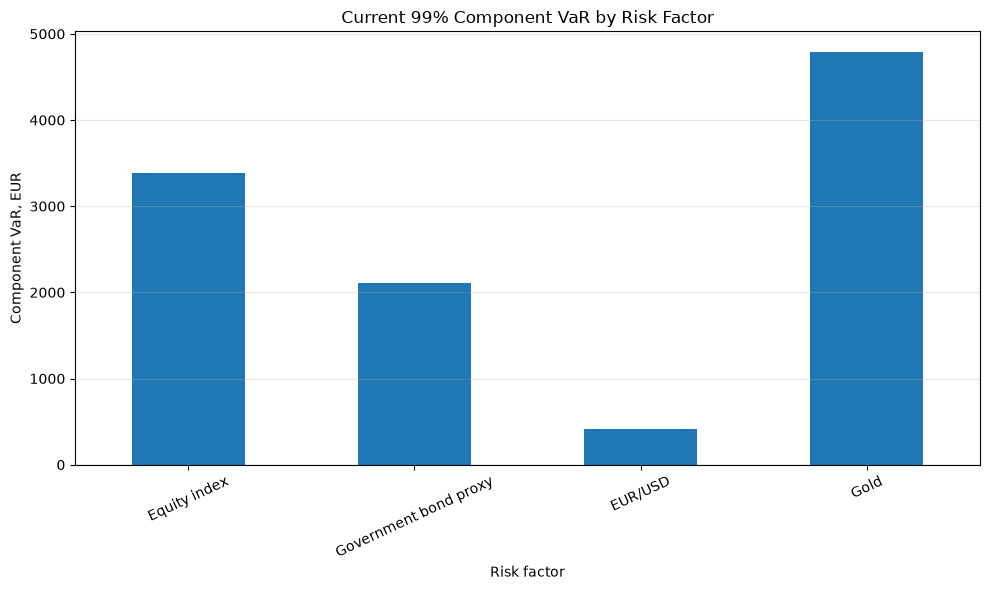

In [10]:
fig_component_var, ax = plt.subplots(
    figsize=(10, 6)
)

component_var_results[
    "component_var_eur"
].plot(
    kind="bar",
    ax=ax,
)

ax.axhline(
    0,
    linewidth=0.8,
)

ax.set_title(
    "Current 99% Component VaR by Risk Factor"
)
ax.set_xlabel("Risk factor")
ax.set_ylabel("Component VaR, EUR")

ax.tick_params(
    axis="x",
    rotation=25,
)

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

In [11]:
component_var_results.to_csv(
    TABLES_DIR / "component_var_results.csv",
    index=True,
)

risk_concentration_comparison.to_csv(
    TABLES_DIR / "risk_concentration_comparison.csv",
    index=True,
)

fig_component_var.savefig(
    CHARTS_DIR / "component_var_by_risk_factor.png",
    dpi=300,
    bbox_inches="tight",
)

print("Initial Day 4 risk-decomposition outputs saved.")

Initial Day 4 risk-decomposition outputs saved.
